<a href="https://colab.research.google.com/github/JNario31/LinearModels/blob/main/LogisticRegresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# download MNIST data from Google drive

!gdown --folder https://drive.google.com/drive/folders/1r20aRjc2iu9O3kN3Xj9jNYY2uMgcERY1 2> /dev/null

# install python_mnist

!pip install python_mnist

Processing file 1Jf2XqGR7y1fzOZNKLJiom7GmZZUzXhfs t10k-images-idx3-ubyte
Processing file 1qiYu9dW3ZNrlvTFO5fI4qf8Wtr8K-pCu t10k-labels-idx1-ubyte
Processing file 1SnWvBcUETRJ53rEJozFUUo-hOQFPKxjp train-images-idx3-ubyte
Processing file 1kKEIi_pwVHmabByAnwZQsaMgro9XiBFE train-labels-idx1-ubyte


In [2]:
#load MINST images

from mnist import MNIST
import numpy as np

# Because images are grey scale pixel values range from 0 to 255
# Divided each pixel value by 255 so each pixel value is scaled from 0 to 1
mnist_loader = MNIST('MNIST')
train_data, train_label = mnist_loader.load_training()
test_data, test_label = mnist_loader.load_testing()
train_data = np.array(train_data, dtype='float')/255 # norm to [0,1]
train_label = np.array(train_label, dtype='short')
test_data = np.array(test_data, dtype='float')/255 # norm to [0,1]
test_label = np.array(test_label, dtype='short')

#add small random noise to avoid matrix singularity
train_data += np.random.normal(0,0.0001,train_data.shape)

print(train_data.shape, train_label.shape, test_data.shape, test_label.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [5]:
# prepare digits '3' and '8' for logisic regression

digit_train_index = np.logical_or(train_label == 3, train_label == 8)
X_train = train_data[digit_train_index]
y_train = train_label[digit_train_index]
digit_test_index = np.logical_or(test_label == 3, test_label == 8)
X_test = test_data[digit_test_index]
y_test = test_label[digit_test_index]

# Add column 1 for the bias term
X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1), dtype=X_train.dtype)))
X_test = np.hstack((X_test, np.ones((X_test.shape[0], 1), dtype=X_test.dtype)))

# converge labels: '3' => -1, '8' => +1
CUTOFF = 5 # any number between '3' and '8'

# all values labeled 3 becomes -1
y_train = np.sign(y_train-CUTOFF)

# all values labeled 8 become 1
y_test = np.sign(y_test-CUTOFF)

In [6]:
# solve logistic regression using mini-batch gradient descent
import numpy as np
import jax.numpy as jnp
from jax import grad

class Optimizer():
  def __init__(self, lr, annealing_rate, batch_size, max_epochs):
    self.lr = lr                          # Initial learning rate
    self.annealing_rate = annealing_rate  # Learning rate decay
    self.batch_size = batch_size          # Batch size
    self.max_epochs = max_epochs          # Max dataset iterations

# sigmoid for numpy arrays
# maps any real valued number into interval (0,1)
# transform the linear combination of inputs into a probability
def sigmoid(x):
  return 1/(1 + jnp.exp(-x))

# the objective function of logistic regression
# inputs: w - weight, X - feature matrix, y - labels
# Dot product of weight and feature matrix, then multiplied by label (remember label is either -1 or 1)
# if after the multiplication the result is negative, there has been a misclassification
# when fed to the sigmoid function, the result produces a value close to 1 for correct classification,
# and close to 0 for a misclassification
# Log converts value once again, if the sigmoid function returns a value close to 1, it is a value close to zero
# after the log, if its close the 0 then it returns a large negative number
# return the average log probability across all samples, convert to a minimization problem
# log(sigmoid(.)) = near 0, if classification is more correct, low loss
# log(sigmoid(.)) = large negative number, if classification is less correct, high loss
def logistic_regression_func(w , X, y):
  return - jnp.mean(jnp.log(sigmoid(y * (X @ w))))   # see the above formula

# X[N,d]: training features; y[N]: training targets;
# X2[N,d]: test features; y2[N]: test targets;
# op: hyper-parameters for optimzer
#
# Note: X2 and y2 are not used in training
#       but only for computting the learning curve B
#
def logistic_regression_gd(X, y, X2, y2, op):
  n = X.shape[0]            # number of samples
  w = jnp.zeros(X.shape[1])  # initialization

  lr = op.lr
  errorsA = np.zeros(op.max_epochs)
  errorsB = np.zeros(op.max_epochs)
  errorsC = np.zeros(op.max_epochs)

  for epoch in range(op.max_epochs):
    indices = np.random.permutation(n)  #randomly shuffle data indices
    for batch_start in range(0, n, op.batch_size):
      X_batch = X[indices[batch_start:batch_start + op.batch_size]]
      y_batch = y[indices[batch_start:batch_start + op.batch_size]]

      # compute gradients with auto-grad for a whole mini-batch
      # compute gradient of loss function with respect to w
      w_grad = grad(logistic_regression_func)(w, X_batch, y_batch)

      # update weight
      w -= lr * w_grad

    # for learning curve C
    # Training loss, regression loss on entire training set
    errorsC[epoch] = logistic_regression_func(w, X, y)   # logisic regression loss function

    # for learning curve A
    # Training accuracy
    # prediction calculated by sign(Xw), maps linear combination to -1 or 1
    # compare the mapped values to true labels y
    predict = np.array(jnp.sign(X @ w))
    errorsA[epoch] = np.count_nonzero(np.equal(predict,y))/y.size

    # for learning curve B
    # test accuracy
    predict2 = np.array(jnp.sign(X2 @ w))
    errorsB[epoch] = np.count_nonzero(np.equal(predict2,y2))/y2.size

    lr *= op.annealing_rate

  print(f'epoch={epoch}: the logistic regression loss is C={errorsC[epoch]:.3f} (A={errorsA[epoch]:.3f},B={errorsB[epoch]:.3f})')
  return w, errorsA, errorsB, errorsC

epoch=49: the logistic regression loss is C=0.093 (A=0.973,B=0.969)


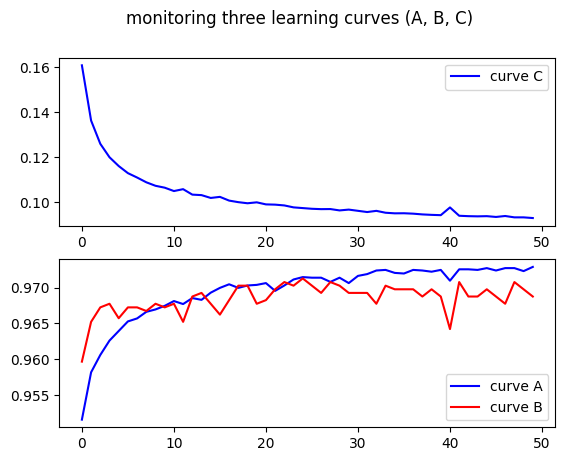

In [7]:
import matplotlib.pyplot as plt

op = Optimizer(lr=0.02, annealing_rate=0.99, batch_size=20, max_epochs=50)

w, A, B, C = logistic_regression_gd(X_train, y_train, X_test, y_test, op)

fig, ax = plt.subplots(2)
fig.suptitle('monitoring three learning curves (A, B, C)')
ax[0].plot(C, 'b')
ax[0].legend(['curve C', 'closed-form solution'])

ax[1].plot(A, 'b', B, 'r')
ax[1].legend(['curve A', 'curve B'])

Logistic Regression:

Linear Model - computes a weighted sum of input features, a linear combination z = Xw (X - feature matrix, w weight vector)

Sigmoid function - output of the linear model passes through a sigmoid function, squashes any real value into the range (0,1), and thus can be interpreted as a probability

This model distinguishes between two classes, encoded -1 or +1, and when multiplying the label with z (y * Xw) encourages a high probability when classified correctly, and a low probability when misclassified (1-0).

Loss function passes sigmoid result into a log, when the probability is high i.e. close to 1, it returns a value close to 0, when its lower, i.e. close to 0, it returns a large negative value.

